In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Kết nối DuckDB → PostgreSQL ───────────────────────────────────────────────
PG = "dbname=risk_banking user=namphuong password=2104 host=localhost port=5432"
conn = duckdb.connect()
conn.execute("INSTALL postgres_scanner; LOAD postgres_scanner;")
conn.execute(f"ATTACH '{PG}' AS pg (TYPE postgres);")

# ── Style cho chart ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})
COLORS = {
    "navy":   "#1D4E89", "blue":  "#2E86AB",
    "teal":   "#1D9E75", "green": "#27AE60",
    "amber":  "#E67E22", "red":   "#C0392B",
    "purple": "#8E44AD", "gray":  "#5D6D7E",
}
print("✓ Kết nối thành công — sẵn sàng phân tích")

✓ Kết nối thành công — sẵn sàng phân tích


## 2.1 — IFRS 9 Stage Classification

In [2]:
df_ifrs9 = conn.execute("""
    WITH classified AS (
        SELECT
            issue_month,
            loan_amnt,
            funded_amnt,
            COALESCE(out_prncp, 0)                            AS ead,
            CASE
                WHEN debt_group >= 3                          THEN 3
                WHEN debt_group = 2
                  OR (last_fico_range_low IS NOT NULL
                      AND fico_range_low - last_fico_range_low > 30)
                                                              THEN 2
                ELSE                                               1
            END                                               AS stage,
            CASE
                WHEN funded_amnt > 0
                THEN GREATEST(0,
                    1.0 - (COALESCE(total_pymnt,0)
                         + COALESCE(recoveries,0)
                         - COALESCE(collection_recovery_fee,0))
                    / funded_amnt)
                ELSE 0.45
            END                                               AS lgd,
            CASE debt_group
                WHEN 1 THEN 0.02 WHEN 2 THEN 0.10
                WHEN 3 THEN 0.35 WHEN 4 THEN 0.65
                WHEN 5 THEN 0.90 ELSE    0.02
            END                                               AS pd
        FROM pg.accepted_loans
        WHERE issue_month IS NOT NULL
    )
    SELECT
        stage,
        COUNT(*)                                              AS loan_count,
        ROUND(SUM(ead)/1e6, 2)                                AS total_ead_m,
        ROUND(AVG(lgd)*100, 2)                                AS avg_lgd_pct,
        ROUND(AVG(pd)*100, 2)                                 AS avg_pd_pct,
        ROUND(SUM(pd*lgd*ead * CASE stage
            WHEN 1 THEN 0.1667 ELSE 1.0 END)/1e6, 4)         AS ecl_m,
        ROUND(100.0 * SUM(pd*lgd*ead * CASE stage
            WHEN 1 THEN 0.1667 ELSE 1.0 END)
            / NULLIF(SUM(ead),0), 4)                          AS coverage_ratio_pct
    FROM classified
    GROUP BY stage
    ORDER BY stage
""").df()

print("=== IFRS 9 Stage Summary ===")
print(df_ifrs9.to_string(index=False))
total_ecl = df_ifrs9["ecl_m"].sum()
print(f"\nTổng ECL toàn danh mục: ${total_ecl:,.2f}M")


=== IFRS 9 Stage Summary ===
 stage  loan_count  total_ead_m  avg_lgd_pct  avg_pd_pct   ecl_m  coverage_ratio_pct
     1     1569977      7719.06        23.75        2.00 16.3806              0.2122
     2      400658      1546.70        17.81        2.26 23.0512              1.4904
     3      290066       244.63        41.79       85.93 50.1458             20.4987

Tổng ECL toàn danh mục: $89.58M


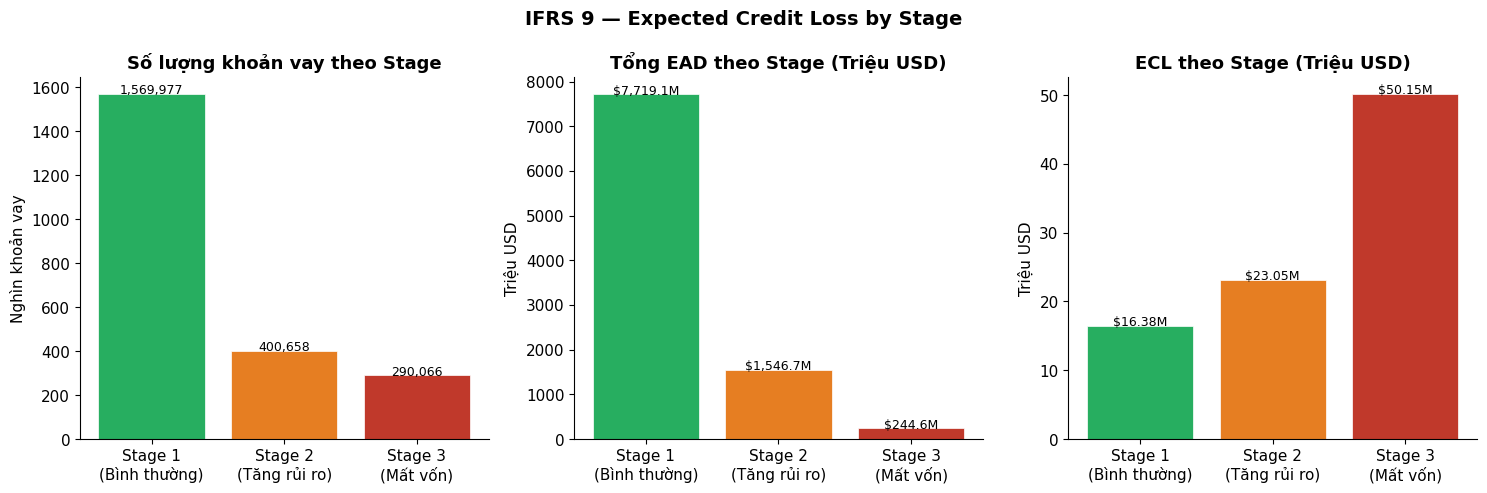

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stage_colors = [COLORS["green"], COLORS["amber"], COLORS["red"]]
stage_labels = ["Stage 1\n(Bình thường)", "Stage 2\n(Tăng rủi ro)", "Stage 3\n(Mất vốn)"]

# Loan count
axes[0].bar(stage_labels, df_ifrs9["loan_count"]/1000,
            color=stage_colors, edgecolor="white", linewidth=0.5)
axes[0].set_title("Số lượng khoản vay theo Stage")
axes[0].set_ylabel("Nghìn khoản vay")
for i, v in enumerate(df_ifrs9["loan_count"]):
    axes[0].text(i, v/1000+0.5, f"{v:,}", ha="center", fontsize=9)

# EAD
axes[1].bar(stage_labels, df_ifrs9["total_ead_m"],
            color=stage_colors, edgecolor="white", linewidth=0.5)
axes[1].set_title("Tổng EAD theo Stage (Triệu USD)")
axes[1].set_ylabel("Triệu USD")
for i, v in enumerate(df_ifrs9["total_ead_m"]):
    axes[1].text(i, v+0.5, f"${v:,.1f}M", ha="center", fontsize=9)

# ECL
axes[2].bar(stage_labels, df_ifrs9["ecl_m"],
            color=stage_colors, edgecolor="white", linewidth=0.5)
axes[2].set_title("ECL theo Stage (Triệu USD)")
axes[2].set_ylabel("Triệu USD")
for i, v in enumerate(df_ifrs9["ecl_m"]):
    axes[2].text(i, v+0.1, f"${v:,.2f}M", ha="center", fontsize=9)

plt.suptitle("IFRS 9 — Expected Credit Loss by Stage", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("m2_ifrs9_stage.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.2 — ECL Trend theo tháng

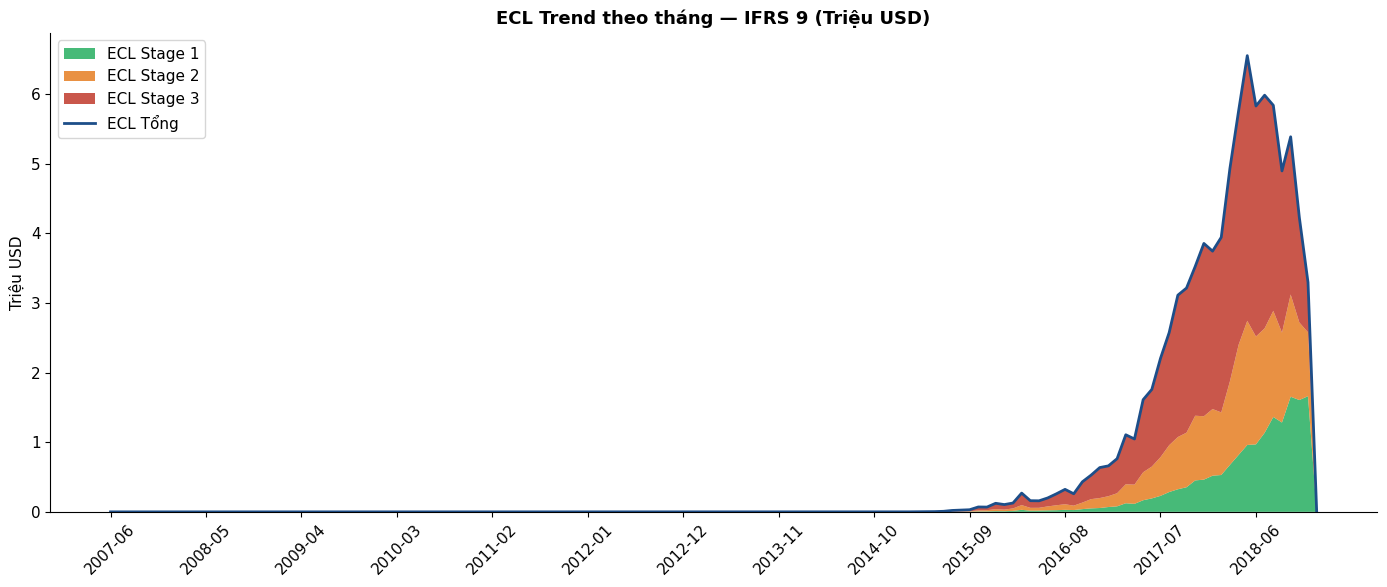

In [4]:
df_ecl = conn.execute("""
    WITH base AS (
        SELECT issue_month,
            CASE WHEN debt_group >= 3 THEN 3
                 WHEN debt_group = 2
                   OR (last_fico_range_low IS NOT NULL
                       AND fico_range_low - last_fico_range_low > 30) THEN 2
                 ELSE 1 END                                   AS stage,
            COALESCE(out_prncp, 0)                            AS ead,
            CASE WHEN funded_amnt > 0
                 THEN GREATEST(0, 1.0 - (COALESCE(total_pymnt,0)
                      + COALESCE(recoveries,0)
                      - COALESCE(collection_recovery_fee,0)) / funded_amnt)
                 ELSE 0.45 END                                AS lgd,
            CASE debt_group
                WHEN 1 THEN 0.02 WHEN 2 THEN 0.10
                WHEN 3 THEN 0.35 WHEN 4 THEN 0.65
                WHEN 5 THEN 0.90 ELSE 0.02 END               AS pd
        FROM pg.accepted_loans WHERE issue_month IS NOT NULL
    )
    SELECT issue_month,
        ROUND(SUM(CASE WHEN stage=1 THEN pd*lgd*ead*0.1667 ELSE 0 END)/1e6,4) AS ecl_s1,
        ROUND(SUM(CASE WHEN stage=2 THEN pd*lgd*ead        ELSE 0 END)/1e6,4) AS ecl_s2,
        ROUND(SUM(CASE WHEN stage=3 THEN pd*lgd*ead        ELSE 0 END)/1e6,4) AS ecl_s3,
        ROUND(SUM(pd*lgd*ead*CASE stage WHEN 1 THEN 0.1667 ELSE 1.0 END)/1e6,4) AS ecl_total
    FROM base GROUP BY issue_month ORDER BY issue_month
""").df()

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(df_ecl["issue_month"],
             df_ecl["ecl_s1"], df_ecl["ecl_s2"], df_ecl["ecl_s3"],
             labels=["ECL Stage 1","ECL Stage 2","ECL Stage 3"],
             colors=[COLORS["green"], COLORS["amber"], COLORS["red"]],
             alpha=0.85)
ax.plot(df_ecl["issue_month"], df_ecl["ecl_total"],
        color=COLORS["navy"], linewidth=2, label="ECL Tổng")
ax.set_title("ECL Trend theo tháng — IFRS 9 (Triệu USD)")
ax.set_ylabel("Triệu USD")
ax.legend(loc="upper left")
step = max(1, len(df_ecl)//12)
ax.set_xticks(df_ecl["issue_month"][::step])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("m2_ecl_trend.png", dpi=150, bbox_inches="tight")
plt.show()
